# Figure 1 F&J: Freely moving augmented reality, system and performance

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env.py
%run run.py connect

2025-02-10 17:02:28,825::INFO::settings.py::Setting loglevel to INFO
2025-02-10 17:02:28,827::INFO::settings.py::Setting stores to {}
2025-02-10 17:02:28,828::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-02-10 17:02:28,829::INFO::settings.py::Setting database.misc.create_tables to True
2025-02-10 17:02:28,830::INFO::settings.py::Setting enable_python_native_blobs to True
2025-02-10 17:02:28,831::INFO::settings.py::Setting database.host to 128.178.51.167:3309
2025-02-10 17:02:28,832::INFO::settings.py::Setting database.user to celia
2025-02-10 17:02:28,833::INFO::settings.py::Setting database.password to celia
2025-02-10 17:02:28,886::INFO::connection.py::Connected celia@128.178.51.167:3309
2025-02-10 17:02:28,907::INFO::table.py::could not log event in table ~log


Connecting celia@128.178.51.167:3309


KeyError: 'DJ_LAB'

In [4]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis, dlc
from vr4mice.analysis.analysis import style
style()

2025-02-10 17:02:29,434::INFO::table.py::could not log event in table ~log
2025-02-10 17:02:29,434::INFO::table.py::could not log event in table ~log


KeyError: 'DJ_LAB'

In [5]:
save_fig_path = "notebooks/Paper_figures/Figure_output/"

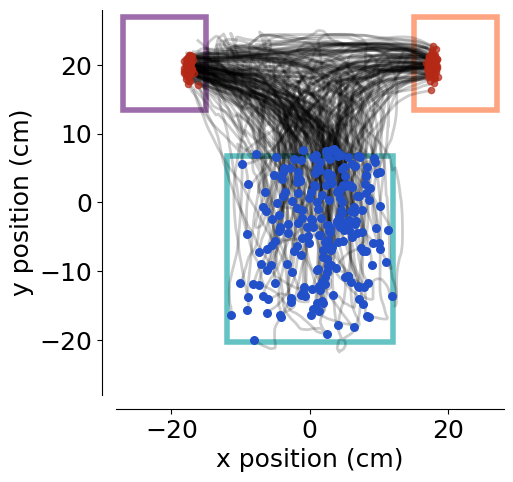

In [ ]:

key = [{"dataset": "Oribi_2024-08-14_1"}, {"dataset": "Pheasant_2024-08-13_1"}]

df = DataFrame().get_data(key=key[0], columns=["dataset", "reward", "x", "y", "trial", "aperture", "iti"])
box_df = base_analysis.BoxDataFrame().get_data(key=key[0])

fig, ax = plt.subplots(1,1, figsize=(5,5))
plotting.plot_session(
    df=df [df.iti == 0.0],
    box_df=box_df,
    per_aperture=False,
    per_side=False,
    ax=ax
)
sns.despine(offset=10)
plt.savefig(save_fig_path + "example_session_trajectory_plot_figure_1J.svg", transparent=True)

In [7]:
key = {"dataset": "Pheasant_2024-08-21_1"}

traces_to_plot = ["head_center_x", "head_center_y", "heading_dir", "head_angle"]
dlc_df = dlc.OfflineKinematics().get_data(key =  key, columns=traces_to_plot)
df = DataFrame().get_data(key=key, columns=["dataset", "reward", "x", "y", "trial", "trial_step", "aperture", "iti"])

In [8]:
df = dlc_df.join(df)
df = df [df.iti == 0.0]

['head_center_x', 'head_center_y', 'heading_dir', 'head_angle'] {'dataset': 'Pheasant_2024-08-21_1'}


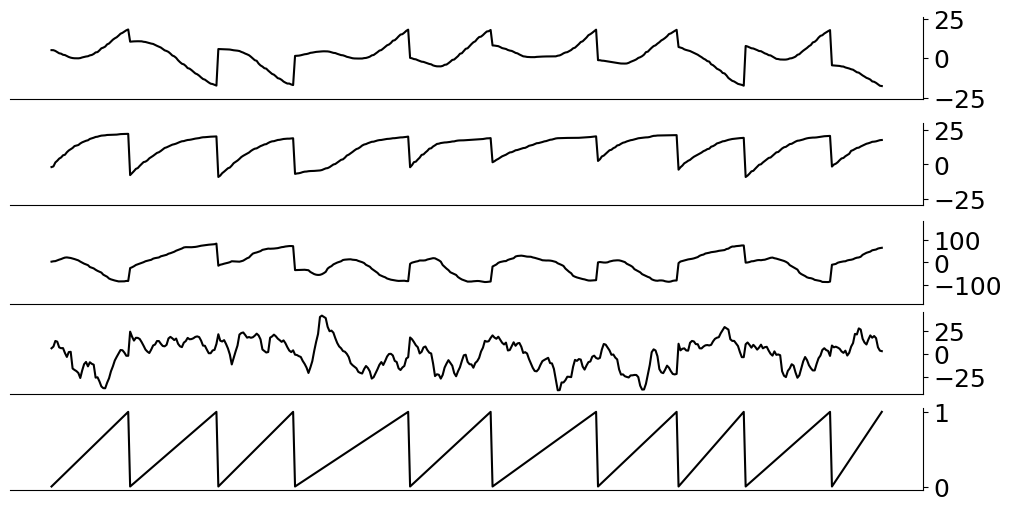

In [9]:
fig, ax = plt.subplots(5,1, figsize = (10,5), sharex=True, constrained_layout=True)
trial =  df [df.trial.isin(range(10,20))].copy().reset_index()
trial ["trial_length"] = trial.groupby(["trial"],as_index=False)["trial_step"].transform(lambda x: x/x.max())

ax[0].plot(trial.x, c="black")
ax[0].set_ylim(-26,26)
ax[0].set_xticks([])

ax[1].plot(trial.y, c="black")
ax[1].set_ylim(-30,30)

ax[2].plot(trial.heading_dir,c="black")
ax[2].set_ylim(-180,180)

ax[3].plot(trial.head_angle, c="black")

ax[4].plot(trial.trial_length, c="black")

plt.rc("axes.spines", top=False, bottom=False, left=False, right=False)
for a in ax:
    a.yaxis.tick_right()  # Moves the ticks to the right
    a.yaxis.set_label_position("right")  # Moves the label to the right
    a.spines['right'].set_position(('outward', 0))  # Adjust the right spine outward
    a.spines['left'].set_visible(False)  # Hide the left spine
    a.spines['right'].set_visible(True)

print(traces_to_plot, key)
plt.savefig(save_fig_path + "behavioural_var_traces_1F.svg", transparent=True)